In [1]:
#install required libs
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

In [2]:
x = np.array([0,1,2,3,4,5,6,7,8,9])
y_true = np.array([20.26, 5.61, 3.14, -30.00, -40.00, -8.13, -11.73, -16.08, -19.95, -24.03])

In [3]:
x_1 = np.array([0,9])
slope , intercept = np.polyfit(x, y_true, 1) #degree 1 for linear fit
y_1 = slope * x_1 + intercept


In [4]:
print(f"Slope: {slope :.2f}")
print(f"Intercept:{intercept :.2f}")

Slope: -3.56
Intercept:3.92


Plot Scatter diagram and Linear Regression Model

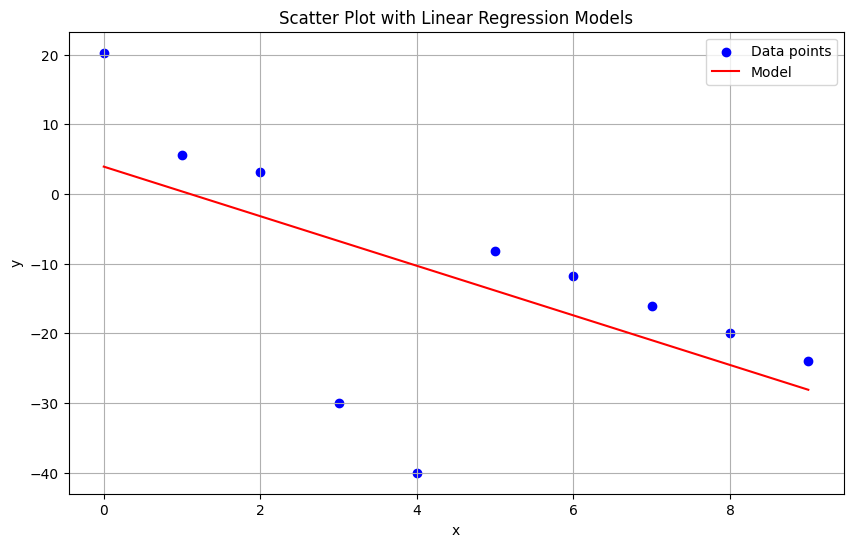

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y_true, color='blue', label='Data points')
plt.plot(x_1, y_1, color='red', label='Model')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot with Linear Regression Models')
plt.legend()
plt.grid(True)
plt.show()

Calculate Loss Function $ L(\theta, \beta) $

In [6]:
x = np.array([0,1,2,3,4,5,6,7,8,9])
y_true = np.array([20.26, 5.61, 3.14, -30.00, -40.00, -8.13, -11.73, -16.08, -19.95, -24.03])
N = len(x)
y_hat1 = -4*x + 12
y_hat2 = -3.55*x + 3.91


In [7]:
def loss(a,b,alpha):
  
    return (a-b)**2 /((a-b)**2+ alpha**2)

In [8]:
def L(y_hat, y_true , beta ):
    N = len(y_hat)
    loss_total = 0
    for i in range(N):
        loss_total += loss(y_hat[i], y_true[i], beta)
        #print(f"Loss for {i}th data point: {loss(y_hat[i], y_true[i], beta)}")
    return loss_total / N


In [9]:
print(f"Model Loss:{L(y_hat1, y_true, 0.1)}")

Model Loss:0.7165184803989848


Model1 -4x + 12

In [10]:
# Model1 -4x + 12 Loss
beta = (1, 10**-6, 10**3)

#beta = 1
L_1 = L(y_hat1, y_true, int(beta[0]))
print(f"Model1 Loss: {L_1}, beta = {beta[0]}")

#beta = 10^-6
L_2 = L(y_hat1, y_true, beta[1])
print(f"Model1 Loss: {L_2}, beta = {beta[1]}")

#beta = 10^3
L_3 = L(y_hat1, y_true, beta[2])
print(f"Model1 Loss: {L_3}, beta = {beta[2]}")

Model1 Loss: 0.435416262490386, beta = 1
Model1 Loss: 0.9999999998258206, beta = 1e-06
Model1 Loss: 0.0002268287498440988, beta = 1000


Model2 -3.55x + 3.91

In [11]:
# Model2 -3.55x + 3.91 Loss

#beta = 1
L_1 = L(y_hat2, y_true, int(beta[0]))
print(f"Model2 Loss: {L_1}, beta = {beta[0]}")

#beta = 10^-6
L_2 = L(y_hat2, y_true, beta[1])
print(f"Model2 Loss: {L_2}, beta = {beta[1]}")

#beta = 10^3
L_3 = L(y_hat2, y_true, beta[2])
print(f"Model2 Loss: {L_3}, beta = {beta[2]}")

Model2 Loss: 0.9728470518681676, beta = 1
Model2 Loss: 0.9999999999999718, beta = 1e-06
Model2 Loss: 0.00018824684654645654, beta = 1000


5. For Model2 suitable $\beta$ value is 1000 as the Loss is minimum

6. Both models are better when $\beta$ is 1000 but model2 appears to have a lesser loss(0.00018824684654645654) compared to model1 loss(0.0002268287498440988).

So model2 (-3.55x + 3.91) is suitable

7. Outliers causes large Losses which will eventually result in increase of overall Loss eventhough other datapoints have low losses.With the use of hyperparameters we can reduce the impact of outliers.As in the robust estimator(L) for large enough hyperparameter($\beta$) we reduce the impact of outliers.

8. We can use Absolute Error(AE) instead of SE because AE is more robust to outliers.

Question 2

In [12]:
y_hat = [0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
y_true = 1

In [32]:


#Mean Squared Error (MSE) 
def MSE(y_hat, y_true):
    
    N = len(y_hat)
    errors = np.zeros(N)
    loss_total = 0
    for i in range(N):
        errors[i] = (y_hat[i] - y_true)**2
        print(f"Loss for {i}th data point: {errors[i]}")
        loss_total += errors[i]
    return loss_total / N , errors
  
#Binary Cross Entropy (BCE)
def BCE(y_hat, y_true):
    N = len(y_hat)
    errors = np.zeros(N)
    loss_total = 0
    for i in range(N):
        if y_hat[i] == 1:
            errors[i] = -y_true * np.log(y_hat[i])
            loss_total += -(y_true)*np.log(y_hat[i])
            print(f"Loss for {i}th data point: {-(y_true)*np.log(y_hat[i])}")
        else:
            errors[i] = -(y_true*np.log(y_hat[i]) + (1-y_true)*np.log(1 - y_hat[i]))
            loss_total += errors[i]
            print(f"Loss for {i}th data point: {errors[i]}")
    return loss_total / N , errors

In [33]:
MSE_value, error_MSE = MSE(y_hat, y_true)

Loss for 0th data point: 0.990025
Loss for 1th data point: 0.9801
Loss for 2th data point: 0.9025
Loss for 3th data point: 0.81
Loss for 4th data point: 0.6400000000000001
Loss for 5th data point: 0.48999999999999994
Loss for 6th data point: 0.36
Loss for 7th data point: 0.25
Loss for 8th data point: 0.16000000000000003
Loss for 9th data point: 0.09000000000000002
Loss for 10th data point: 0.03999999999999998
Loss for 11th data point: 0.009999999999999995
Loss for 12th data point: 0.0


In [34]:
BCE_value, error_BCE = BCE(y_hat, y_true)

Loss for 0th data point: 5.298317366548036
Loss for 1th data point: 4.605170185988091
Loss for 2th data point: 2.995732273553991
Loss for 3th data point: 2.3025850929940455
Loss for 4th data point: 1.6094379124341003
Loss for 5th data point: 1.2039728043259361
Loss for 6th data point: 0.916290731874155
Loss for 7th data point: 0.6931471805599453
Loss for 8th data point: 0.5108256237659907
Loss for 9th data point: 0.35667494393873245
Loss for 10th data point: 0.2231435513142097
Loss for 11th data point: 0.10536051565782628
Loss for 12th data point: -0.0


In [31]:
print("MSE Value:", MSE_value)
print("BCE Value:", BCE_value)

MSE Value: 0.44020192307692313
BCE Value: 1.601589090996543


In [35]:
print("MSE Errors:", error_MSE)
print("BCE Errors:", error_BCE) 

MSE Errors: [0.990025 0.9801   0.9025   0.81     0.64     0.49     0.36     0.25
 0.16     0.09     0.04     0.01     0.      ]
BCE Errors: [ 5.29831737  4.60517019  2.99573227  2.30258509  1.60943791  1.2039728
  0.91629073  0.69314718  0.51082562  0.35667494  0.22314355  0.10536052
 -0.        ]


| True \( y \) | Prediction(y_hat)        | MSE     | BCE      |
|--------------|--------------------------|---------|----------|
| 1            | 0.005                    | 0.990025| 5.2983   |
| 1            | 0.01                     | 0.9801  | 4.6052   |
| 1            | 0.05                     | 0.9025  | 2.9957   |
| 1            | 0.1                      | 0.81    | 2.3026   |
| 1            | 0.2                      | 0.64    | 1.6094   |
| 1            | 0.3                      | 0.49    | 1.2039   |
| 1            | 0.4                      | 0.36    | 0.9163   |
| 1            | 0.5                      | 0.25    | 0.6931   |
| 1            | 0.6                      | 0.16    | 0.5108   |
| 1            | 0.7                      | 0.09    | 0.3567   |
| 1            | 0.8                      | 0.04    | 0.2231   |
| 1            | 0.9                      | 0.01    | 0.1054   |
| 1            | 1.0                      | 0.0     | 0.0      |

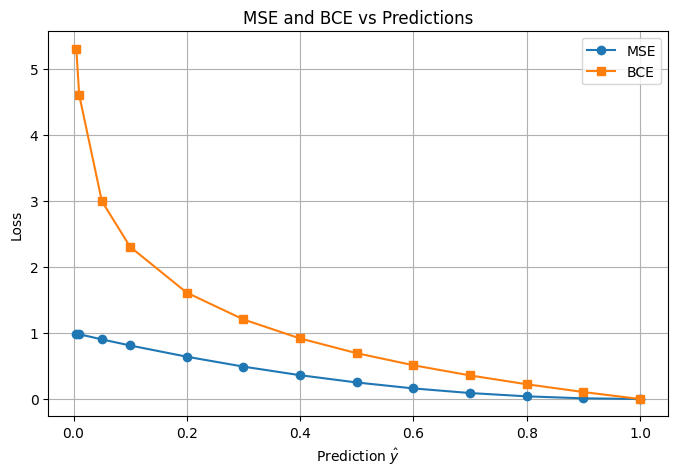

In [39]:

y = 1
y_pred = np.array([0.005,0.01,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0])


# Plot
plt.figure(figsize=(8,5))
plt.plot(y_pred, error_MSE, 'o-', label='MSE')
plt.plot(y_pred, error_BCE, 's-', label='BCE')
plt.xlabel('Prediction $\hat{y}$')
plt.ylabel('Loss')
plt.title('MSE and BCE vs Predictions')
plt.legend()
plt.grid(True)
plt.show()


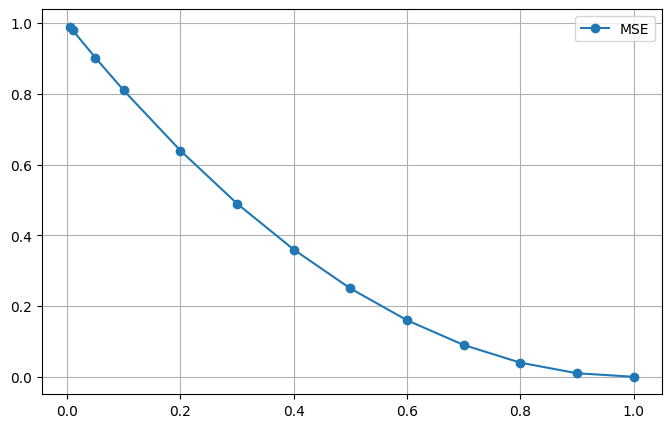

In [38]:
plt.figure(figsize=(8,5))
plt.plot(y_pred, error_MSE, 'o-', label='MSE')
plt.legend()
plt.grid(True)
plt.show()

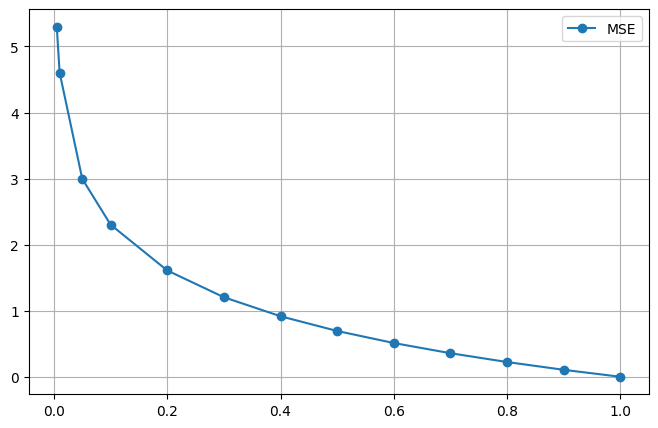

In [37]:
plt.figure(figsize=(8,5))
plt.plot(y_pred, error_BCE, 'o-', label='MSE')
plt.legend()
plt.grid(True)
plt.show()

2. For application 1 MSE is suitable while for application 2 is BCE is suitable.In a continuous variable application we cannot define BCE function properly so for application 1 we use MSE.For applications in logistic regression type we can use BCE because we can define loss function on discrete levels.So for application 2 we use BCE

Question 3 

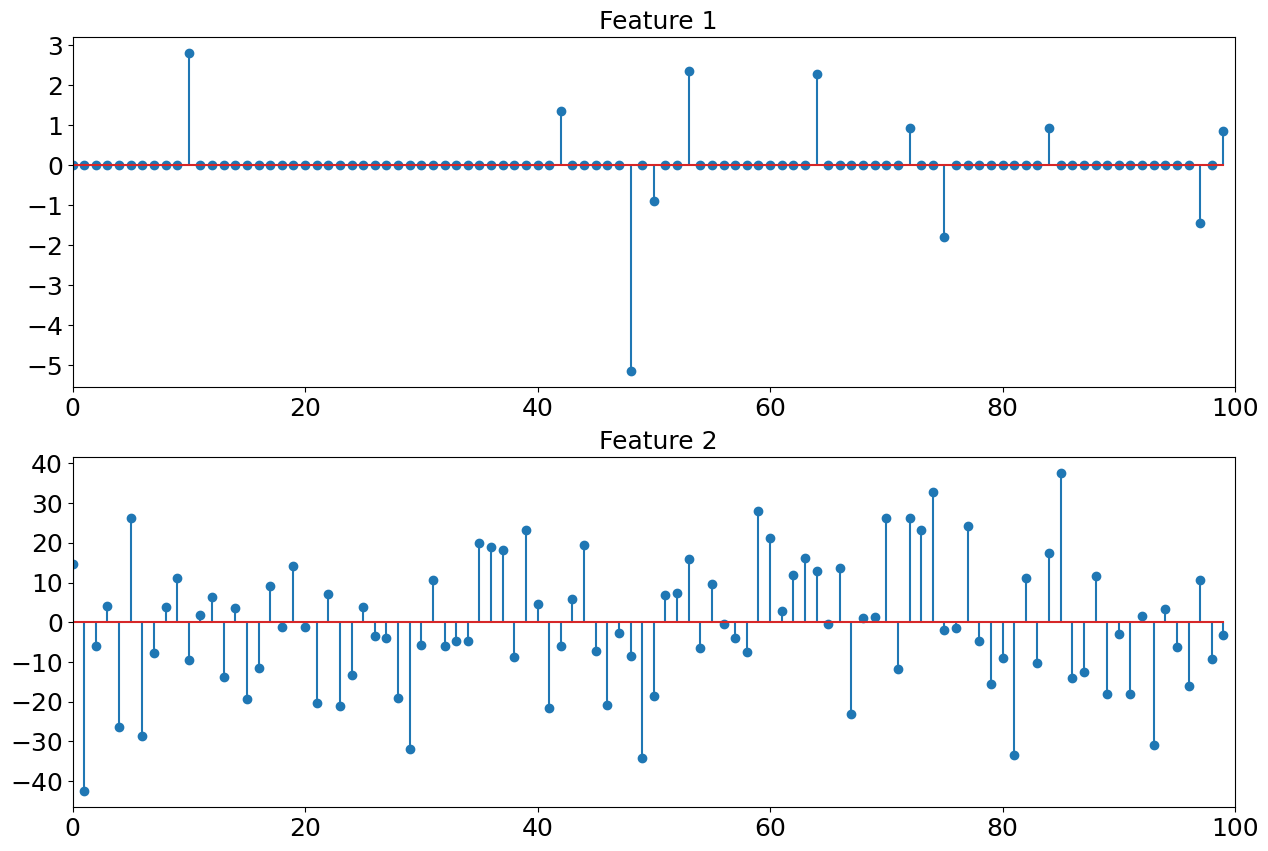

In [19]:
import numpy as np
import matplotlib . pyplot as plt

def generate_signal ( signal_length , num_nonzero ) :
    signal = np . zeros ( signal_length )
    nonzero_indices = np . random . choice ( signal_length , num_nonzero ,
    replace = False )
    nonzero_values = 10* np . random . randn ( num_nonzero )
    signal [ nonzero_indices ] = nonzero_values
    return signal
  
signal_length = 100 # Total length of the signal
num_nonzero = 10 # Number of non - zero elements in the signal
your_index_no = 220472 # Enter your index no without english letters and without leading zeros
sparse_signal = generate_signal ( signal_length , num_nonzero )
sparse_signal [10] = ( your_index_no % 10) *2 + 10
if your_index_no % 10 == 0:
    sparse_signal [10] = np . random . randn (1) + 30
sparse_signal = sparse_signal /5
epsilon = np . random . normal (0 , 15 , signal_length )

# epsilon = epsilon [: , np. newaxis ]
plt . figure ( figsize =(15 ,10) )
plt . subplot (2 , 1 , 1)
plt . xlim (0 , signal_length )
plt . title (" Feature 1", fontsize =18)
plt . xticks ( fontsize =18) # Adjust x- axis tick label font size
plt . yticks ( fontsize =18)
plt . stem ( sparse_signal )
plt . subplot (2 , 1 , 2)
plt . xlim (0 , signal_length )
plt . title (" Feature 2", fontsize =18)
plt . stem ( epsilon )
plt . xticks ( fontsize =18) # Adjust x- axis tick label font size
plt . yticks ( fontsize =18)
plt . show ()


In [20]:
feature_1 = sparse_signal
feature_2 = epsilon
feature_1 = feature_1.reshape(-1, 1)
feature_2 = feature_2.reshape(-1, 1)

(a)Standard scaling

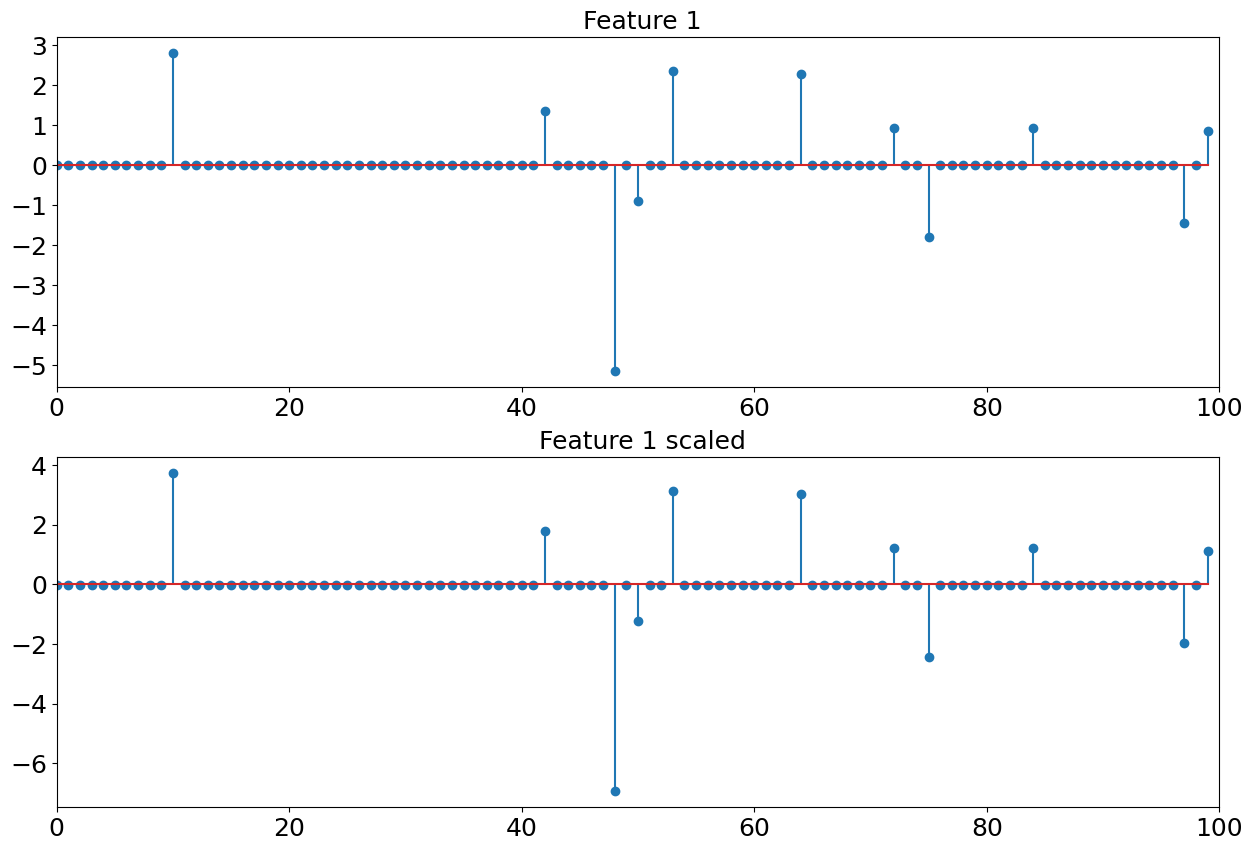

In [21]:

scaler1 = StandardScaler()

feature_1_scaled = scaler1.fit_transform(feature_1)


plt . figure ( figsize =(15 ,10) )
plt . subplot (2 , 1 , 1)
plt . xlim (0 , signal_length )
plt . title (" Feature 1", fontsize =18)
plt . xticks ( fontsize =18) # Adjust x- axis tick label font size
plt . yticks ( fontsize =18)
plt . stem ( feature_1 )
plt . subplot (2 , 1 , 2)
plt . xlim (0 , signal_length )
plt . title (" Feature 1 scaled", fontsize =18)
plt . stem ( feature_1_scaled )
plt . xticks ( fontsize =18) # Adjust x- axis tick label font size
plt . yticks ( fontsize =18)
plt . show ()





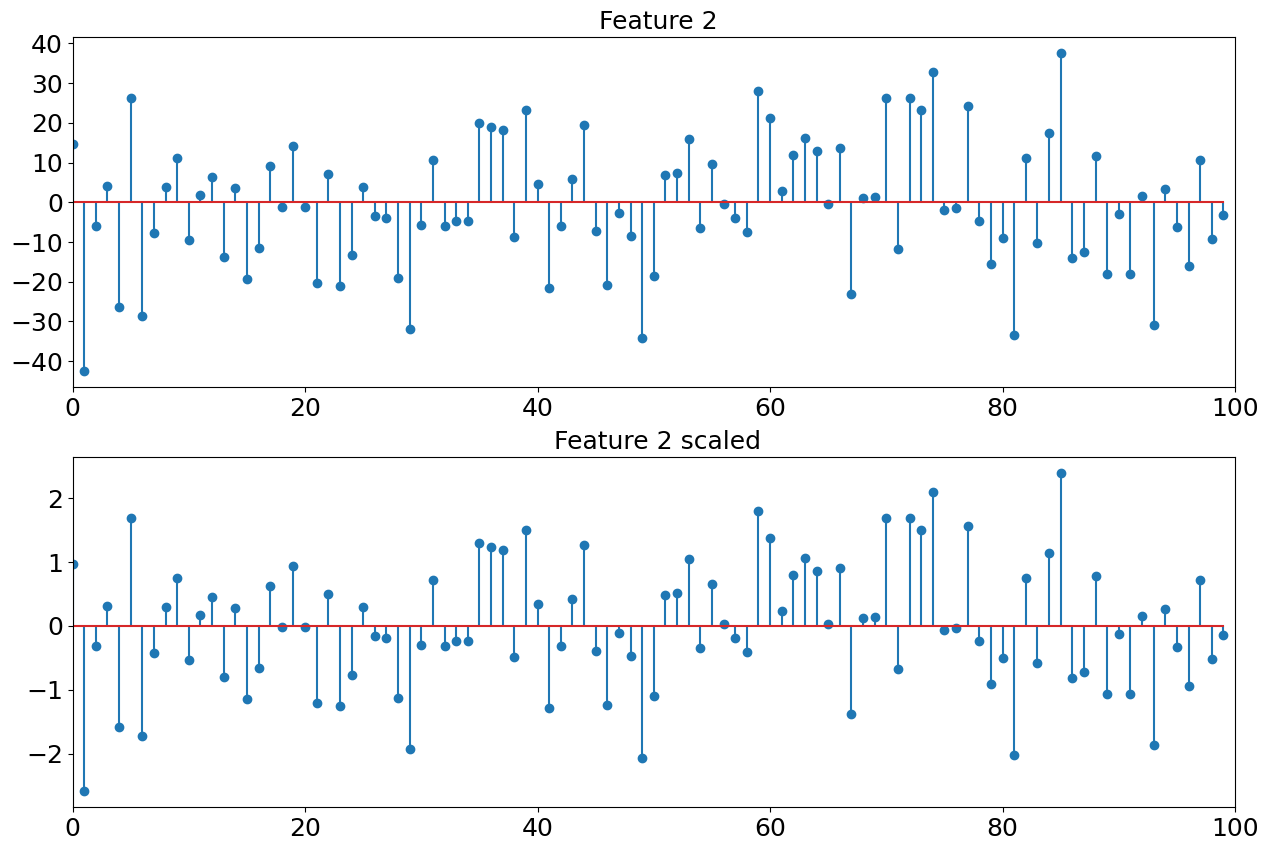

In [22]:

feature_2_scaled = scaler1.fit_transform(feature_2)


plt . figure ( figsize =(15 ,10) )
plt . subplot (2 , 1 , 1)
plt . xlim (0 , signal_length )
plt . title (" Feature 2", fontsize =18)
plt . xticks ( fontsize =18) # Adjust x- axis tick label font size
plt . yticks ( fontsize =18)
plt . stem ( feature_2 )
plt . subplot (2 , 1 , 2)
plt . xlim (0 , signal_length )
plt . title (" Feature 2 scaled", fontsize =18)
plt . stem ( feature_2_scaled )
plt . xticks ( fontsize =18) # Adjust x- axis tick label font size
plt . yticks ( fontsize =18)
plt . show ()

(b)Min-Max Scaling

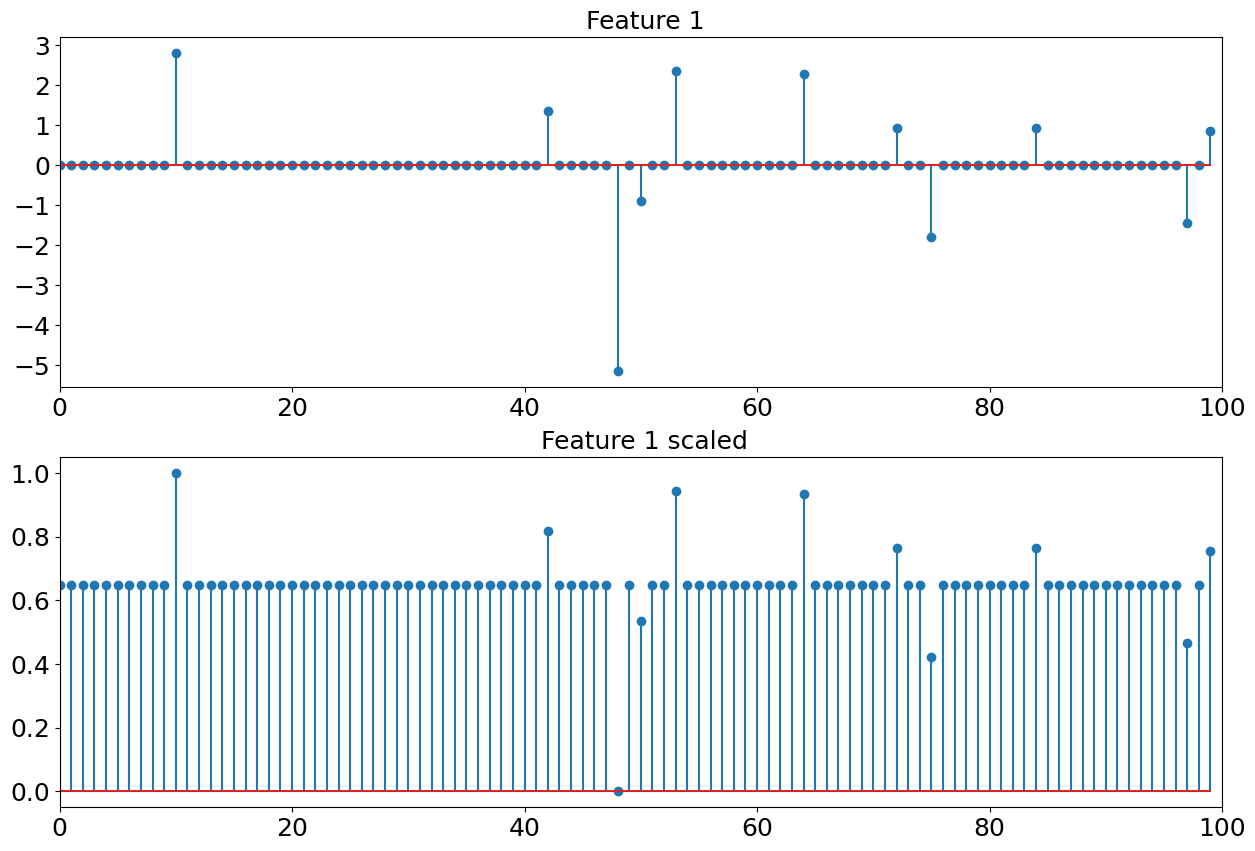

In [23]:
scaler2 = scaler2 = MinMaxScaler() 

feature_1_scaled = scaler2.fit_transform(feature_1)


plt . figure ( figsize =(15 ,10) )
plt . subplot (2 , 1 , 1)
plt . xlim (0 , signal_length )
plt . title (" Feature 1", fontsize =18)
plt . xticks ( fontsize =18) # Adjust x- axis tick label font size
plt . yticks ( fontsize =18)
plt . stem ( feature_1 )
plt . subplot (2 , 1 , 2)
plt . xlim (0 , signal_length )
plt . title (" Feature 1 scaled", fontsize =18)
plt . stem ( feature_1_scaled )
plt . xticks ( fontsize =18) # Adjust x- axis tick label font size
plt . yticks ( fontsize =18)
plt . show ()

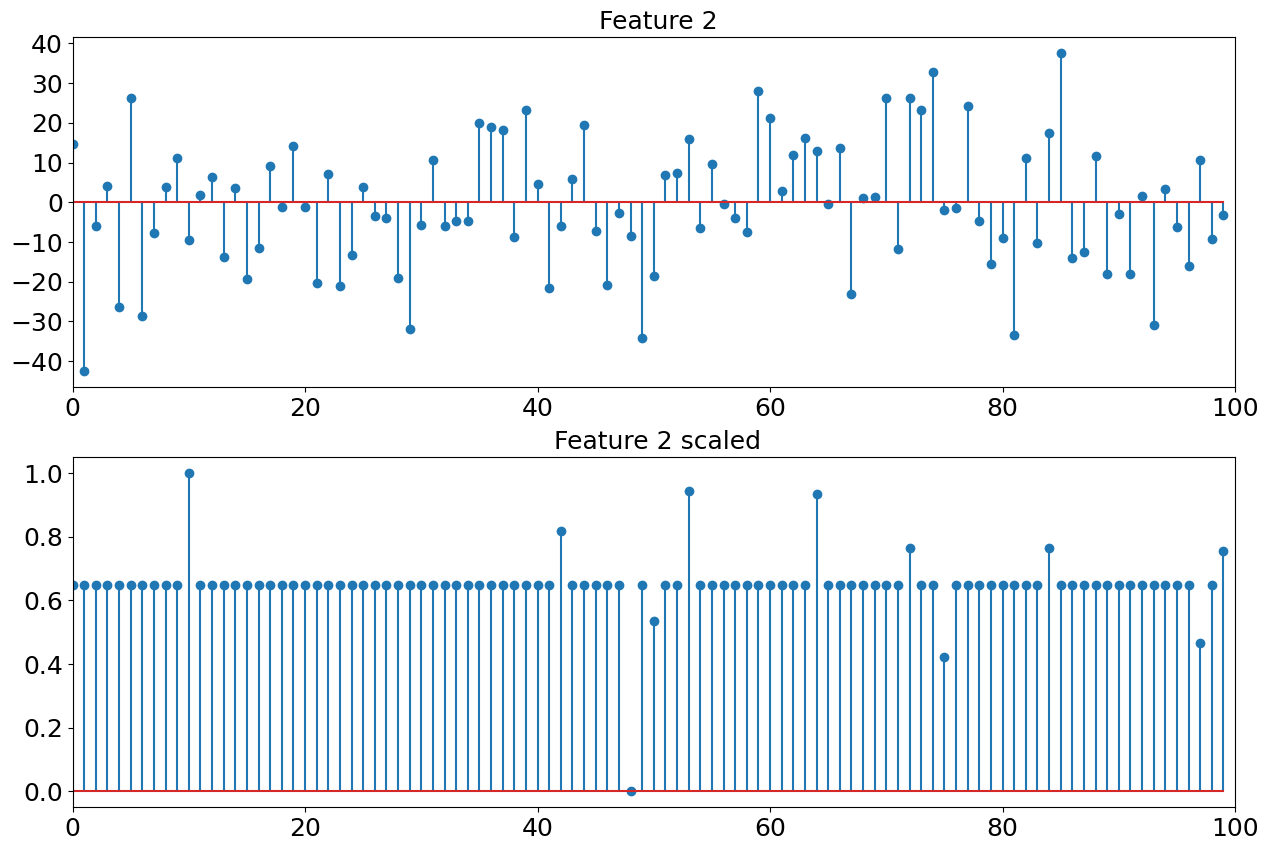

In [24]:

feature_2_scaled = scaler2.fit_transform(feature_1)


plt . figure ( figsize =(15 ,10) )
plt . subplot (2 , 1 , 1)
plt . xlim (0 , signal_length )
plt . title (" Feature 2", fontsize =18)
plt . xticks ( fontsize =18) # Adjust x- axis tick label font size
plt . yticks ( fontsize =18)
plt . stem ( feature_2 )
plt . subplot (2 , 1 , 2)
plt . xlim (0 , signal_length )
plt . title (" Feature 2 scaled", fontsize =18)
plt . stem ( feature_2_scaled )
plt . xticks ( fontsize =18) # Adjust x- axis tick label font size
plt . yticks ( fontsize =18)
plt . show ()

(c)Max-Abs Scaling

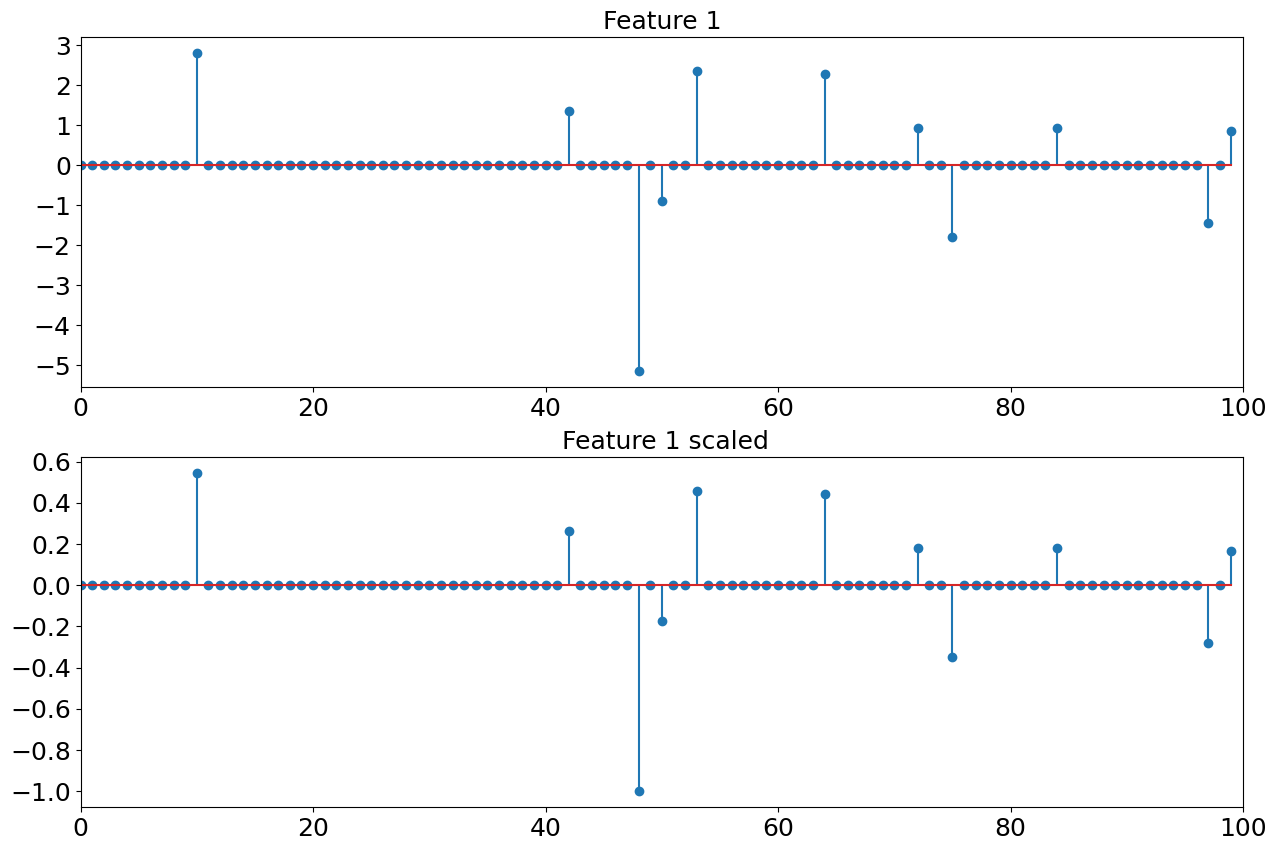

In [25]:
scaler3 = MaxAbsScaler()

feature_1_scaled = scaler3.fit_transform(feature_1)

plt . figure ( figsize =(15 ,10) )
plt . subplot (2 , 1 , 1)
plt . xlim (0 , signal_length )
plt . title (" Feature 1 ", fontsize =18)
plt . xticks ( fontsize =18) # Adjust x- axis tick label font size
plt . yticks ( fontsize =18)
plt . stem ( feature_1 )
plt . subplot (2 , 1 , 2)
plt . xlim (0 , signal_length )
plt . title (" Feature 1 scaled", fontsize =18)
plt . stem ( feature_1_scaled )
plt . xticks ( fontsize =18) # Adjust x- axis tick label font size
plt . yticks ( fontsize =18)
plt . show ()



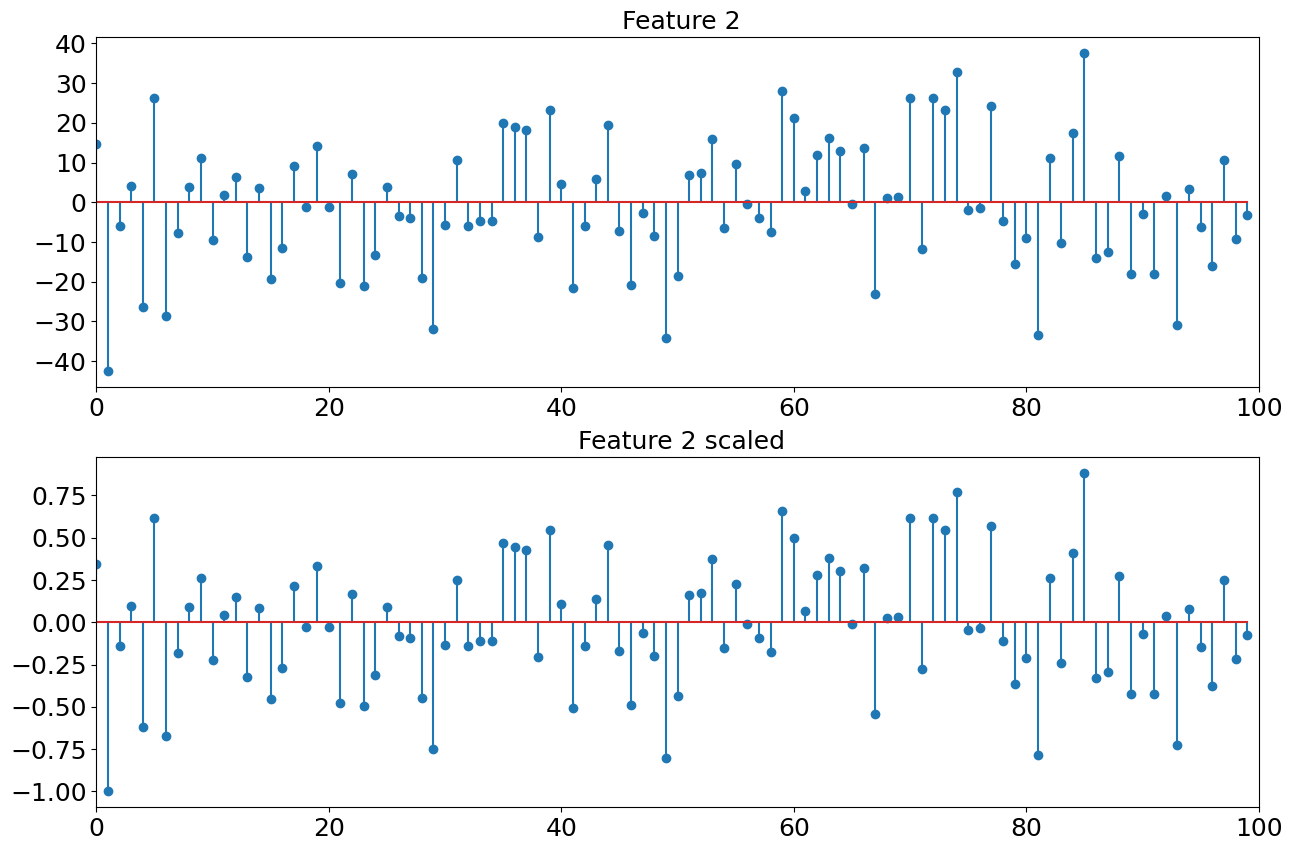

In [26]:
feature_2_scaled = scaler3.fit_transform(feature_2)

plt . figure ( figsize =(15 ,10) )
plt . subplot (2 , 1 , 1)
plt . xlim (0 , signal_length )
plt . title (" Feature 2", fontsize =18)
plt . xticks ( fontsize =18) # Adjust x- axis tick label font size
plt . yticks ( fontsize =18)
plt . stem ( feature_2 )
plt . subplot (2 , 1 , 2)
plt . xlim (0 , signal_length )
plt . title (" Feature 2 scaled", fontsize =18)
plt . stem ( feature_2_scaled )
plt . xticks ( fontsize =18) # Adjust x- axis tick label font size
plt . yticks ( fontsize =18)
plt . show ()

As we can observe in plots method (b) Min-Max scaler is not optimal for scaling the features as it does not preserve the structure of the features.

Both (a) Standard Scaler and (c) Max- Abs Scaler preserve the structue of the features yet (c) Max- Abs Scaler always prserve the structure with features beign scaled within 0-1. This is not achievable in (a) Standard Scaler always as it depends on mean and standard deviation.

So the optimal scaling is the (c) Max- Abs Scaler.